In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [41]:
import pandas as pd

gse63060 = pd.read_csv(
    "GSE63060_non-normalized.txt.gz",
    sep="\t",
    compression="gzip"
)

In [42]:
gse63060.head()

,IND_ID,4856076025_A.AVG_Signal,4856050046_J.AVG_Signal,4856076025_K.AVG_Signal,4856076002_I.AVG_Signal,4856076007_I.AVG_Signal,4856076026_I.AVG_Signal,4856076025_B.AVG_Signal,4856076027_A.AVG_Signal,4856076029_H.AVG_Signal,...,4856050009_G.AVG_Signal,Unnamed: 322,4856076025_C.AVG_Signal,4856050047_L.AVG_Signal,4856076008_L.AVG_Signal,4856076027_C.AVG_Signal,4856076041_F.AVG_Signal,Unnamed: 328,4856076028_A.AVG_Signal,4856076038_D.AVG_Signal
0,ILMN_1762337,102.9087,111.9824,114.1762,105.47530,119.2129,95.56101,108.37660,96.45403,109.8408,...,115.4296,115.0052,102.3502,120.2517,129.1860,96.30216,116.4330,111.5879,117.9205,105.05180
1,ILMN_2055271,124.4287,128.5884,144.6195,127.50830,128.9708,128.79030,107.89980,109.16030,134.0712,...,129.5616,143.5464,110.0619,141.0523,157.4733,115.30250,131.0094,126.8994,158.3018,122.12820
2,ILMN_1736007,122.9408,122.9054,136.7244,100.75240,120.6690,93.47369,108.58740,105.66970,126.8941,...,112.1638,131.7312,127.2694,117.1613,154.7839,111.12640,112.2209,123.5492,118.7930,93.93628
3,ILMN_2383229,117.8198,129.8000,119.1177,96.82175,106.7139,110.77650,93.67871,92.46908,122.8994,...,106.0917,109.6046,111.5465,106.8955,141.0002,100.38780,108.3385,112.5710,113.4874,109.42230
4,ILMN_1806310,118.3661,128.3122,119.8891,120.57680,125.7108,106.11640,108.98890,92.47576,115.2288,...,129.4048,114.5319,101.3159,119.2947,145.3832,96.03426,139.0625,114.7319,121.5900,122.22130


In [43]:
gse63060.shape

(48803, 331)

In [44]:
gse63060.columns[:10]

Index(['IND_ID', '4856076025_A.AVG_Signal', '4856050046_J.AVG_Signal',
       '4856076025_K.AVG_Signal', '4856076002_I.AVG_Signal',
       '4856076007_I.AVG_Signal', '4856076026_I.AVG_Signal',
       '4856076025_B.AVG_Signal', '4856076027_A.AVG_Signal',
       '4856076029_H.AVG_Signal'],
      dtype='object')

In [45]:
gse63060['IND_ID'].head()
gse63060.iloc[:5, :5]

,IND_ID,4856076025_A.AVG_Signal,4856050046_J.AVG_Signal,4856076025_K.AVG_Signal,4856076002_I.AVG_Signal
0,ILMN_1762337,102.9087,111.9824,114.1762,105.47530
1,ILMN_2055271,124.4287,128.5884,144.6195,127.50830
2,ILMN_1736007,122.9408,122.9054,136.7244,100.75240
3,ILMN_2383229,117.8198,129.8000,119.1177,96.82175
4,ILMN_1806310,118.3661,128.3122,119.8891,120.57680


In [46]:
with open("GSE63060_series_matrix.txt", "r") as f:
    for i in range(20):
        print(f.readline())

!Series_title	"Alzheimer, MCI and control samples from AddneuroMed Cohort (batch 1)"

!Series_geo_accession	"GSE63060"

!Series_status	"Public on Aug 05 2015"

!Series_submission_date	"Nov 06 2014"

!Series_last_update_date	"May 30 2024"

!Series_pubmed_id	"26343147"

!Series_summary	"Alzheimer case-control samples originate from the EU funded AddNeuroMed Cohort, which is a large cross-European AD biomarker study relying on human blood as the source of RNA."

!Series_overall_design	"The design is case-control. Cases are either Alzheimer's disease patients, subjects with mild cognitive impairment or age and gender matched controls."

!Series_type	"Expression profiling by array"

!Series_contributor	"Angela,,Hodges"

!Series_contributor	"Robert,,Howard"

!Series_sample_id	"GSM1539080 GSM1539081 GSM1539082 GSM1539083 GSM1539084 GSM1539085 GSM1539086 GSM1539087 GSM1539088 GSM1539089 GSM1539090 GSM1539091 GSM1539092 GSM1539093 GSM1539094 GSM1539095 GSM1539096 GSM1539097 GSM1539098 GSM153909

In [47]:
with open("GSE63060_series_matrix.txt", "r") as f:
    lines = f.readlines()

for line in lines:
    if "!Sample_characteristics_ch1" in line:
        print(line[:2000])
        break

!Sample_characteristics_ch1	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: MCI"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"status: CTL"	"statu

In [48]:
for line in lines:
    if "!Sample_title" in line:
        print(line[:1000])
        break

!Sample_title	"4856050008_I"	"4856050047_D"	"4856076009_D"	"4856076040_F"	"4856076002_E"	"4856076041_H"	"4856076040_G"	"4856076023_G"	"4856076040_C"	"4856050047_B"	"4856076019_E"	"4856050046_D"	"4856076028_K"	"4856076026_C"	"4856050009_B"	"4856076027_G"	"4856076017_C"	"4856076025_H"	"4856076027_B"	"4856076040_A"	"4856050003_E"	"4856050007_A"	"4856050048_L"	"4856050007_J"	"4856050008_G"	"4856050058_K"	"4856076018_J"	"4856050007_K"	"4856050058_E"	"4856076042_K"	"4856076028_C"	"4856076019_H"	"4856076029_A"	"4856076008_J"	"4856076025_I"	"4856076026_J"	"4856076003_B"	"4856050059_C"	"4856076042_D"	"4856076007_H"	"4856050048_J"	"4856076029_D"	"4856050048_B"	"4856076038_J"	"4856076007_G"	"4856076017_F"	"4856076027_K"	"4856076007_F"	"4856076009_A"	"4856076038_H"	"4856076009_G"	"4856076023_I"	"4856076023_F"	"4856076025_G"	"4856076008_H"	"4856076023_L"	"4856076027_H"	"4856076023_H"	"4856076003_G"	"4856076019_F"	"4856050059_F"	"4856076002_D"	"4856076030_K"	"4856050048_H"	"4856050047_J"	"4856050059

In [49]:
for line in lines:
    if "!Sample_characteristics_ch1" in line:
        status_line = line
        break

status_line[:500]

'!Sample_characteristics_ch1\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: MCI"\t"status: M'

In [50]:
statuses = status_line.split("\t")[1:]

statuses = [s.replace('"','').replace('status: ','') for s in statuses]

from collections import Counter

Counter(statuses)

Counter({'AD': 145, 'CTL': 104, 'MCI': 79, 'MCI\n': 1})

In [51]:
for line in lines:
    if "!Sample_title" in line:
        title_line = line
        break

titles = title_line.split("\t")[1:]

titles = [t.replace('"','').strip() for t in titles]

titles[:10]

['4856050008_I',
 '4856050047_D',
 '4856076009_D',
 '4856076040_F',
 '4856076002_E',
 '4856076041_H',
 '4856076040_G',
 '4856076023_G',
 '4856076040_C',
 '4856050047_B']

In [52]:
len(titles)

329

In [53]:
import pandas as pd

statuses = [s.replace('"','').replace('status: ','').strip()
            for s in statuses]

metadata = pd.DataFrame({
    'sample_title': titles,
    'status': statuses
})

metadata.head()

,sample_title,status
0,4856050008_I,MCI
1,4856050047_D,MCI
2,4856076009_D,MCI
3,4856076040_F,MCI
4,4856076002_E,MCI


In [54]:
metadata.shape

(329, 2)

In [55]:
expr_samples = [col.replace('.AVG_Signal','')
                for col in gse63060.columns[1:]]

expr_samples[:10]

['4856076025_A',
 '4856050046_J',
 '4856076025_K',
 '4856076002_I',
 '4856076007_I',
 '4856076026_I',
 '4856076025_B',
 '4856076027_A',
 '4856076029_H',
 '4856076026_G']

In [56]:
len(expr_samples)

330

In [57]:
set(expr_samples) - set(titles)

{'4856076038_D', 'Unnamed: 316', 'Unnamed: 322', 'Unnamed: 328'}

In [58]:
set(titles) - set(expr_samples)

{'4856050008_B', '4856050008_K', '4856050048_A'}

In [59]:
gse63060[['Unnamed: 316', 'Unnamed: 322', 'Unnamed: 328']].head()

,Unnamed: 316,Unnamed: 322,Unnamed: 328
0,96.79610,115.0052,111.5879
1,102.88940,143.5464,126.8994
2,112.48680,131.7312,123.5492
3,89.11185,109.6046,112.5710
4,124.52060,114.5319,114.7319


In [60]:
[col for col in gse63060.columns if "Unnamed" in str(col)]

['Unnamed: 316', 'Unnamed: 322', 'Unnamed: 328']

In [61]:
gse63060.columns[310:320]

Index(['4856050008_E.AVG_Signal', '4856076040_L.AVG_Signal',
       '4856076029_F.AVG_Signal', '4856050048_F.AVG_Signal',
       '4856050003_J.AVG_Signal', '4856050058_C.AVG_Signal', 'Unnamed: 316',
       '4856076028_G.AVG_Signal', '4856050046_E.AVG_Signal',
       '4856076008_G.AVG_Signal'],
      dtype='object')

In [62]:
gse63060.columns[320:330]

Index(['4856050048_I.AVG_Signal', '4856050009_G.AVG_Signal', 'Unnamed: 322',
       '4856076025_C.AVG_Signal', '4856050047_L.AVG_Signal',
       '4856076008_L.AVG_Signal', '4856076027_C.AVG_Signal',
       '4856076041_F.AVG_Signal', 'Unnamed: 328', '4856076028_A.AVG_Signal'],
      dtype='object')

In [63]:
len([c for c in gse63060.columns if ".AVG_Signal" in str(c)])

327

In [64]:
expr_samples = [col.replace('.AVG_Signal','')
                for col in gse63060.columns[1:]]

len(expr_samples)

330

In [65]:
len(set(expr_samples))

330

In [66]:
metadata['sample_title'].duplicated().sum()

np.int64(0)

In [67]:
metadata['sample_title'][metadata['sample_title'].duplicated()]

Series([], Name: sample_title, dtype: object)

In [68]:
for line in lines:
    if "4856076038_D" in line:
        print(line[:500])

In [69]:
expr_samples = [c.replace('.AVG_Signal','')
                for c in gse63060.columns[1:]
                if 'Unnamed' not in str(c)]

len(expr_samples)

327

In [70]:
len(set(expr_samples) - set(titles))

1

In [76]:
set(expr_samples) - set(titles)

{'4856076038_D'}

In [77]:
gse63060_clean = gse63060.copy()

gse63060_clean.drop(
    columns=['4856076038_D.AVG_Signal'],
    inplace=True
)
gse63060_clean.shape


(48803, 330)

In [78]:
len(gse63060_clean.columns) - 1

329

In [79]:
[i for i, col in enumerate(gse63060_clean.columns)
 if 'Unnamed' in str(col)]

[316, 322, 328]

In [80]:
for i in range(310, 330):
    print(i, titles[i])

310 4856076022_B
311 4856076022_F
312 4856076022_K
313 4856076023_D
314 4856076025_D
315 4856076025_F
316 4856076025_L
317 4856076026_K
318 4856076027_E
319 4856076029_I
320 4856076029_L
321 4856076030_E
322 4856076038_G
323 4856076041_B
324 4856076018_L
325 4856050009_E
326 4856050046_F
327 4856076026_H
328 4856076028_D


IndexError: list index out of range

In [81]:
for i in range(312, 319):
    print(i, gse63060_clean.columns[i])

312 4856076029_F.AVG_Signal
313 4856050048_F.AVG_Signal
314 4856050003_J.AVG_Signal
315 4856050058_C.AVG_Signal
316 Unnamed: 316
317 4856076028_G.AVG_Signal
318 4856050046_E.AVG_Signal


In [82]:
for i in range(318, 325):
    print(i, gse63060_clean.columns[i])

318 4856050046_E.AVG_Signal
319 4856076008_G.AVG_Signal
320 4856050048_I.AVG_Signal
321 4856050009_G.AVG_Signal
322 Unnamed: 322
323 4856076025_C.AVG_Signal
324 4856050047_L.AVG_Signal


In [83]:
for i in range(324, 330):
    print(i, gse63060.columns[i])

324 4856050047_L.AVG_Signal
325 4856076008_L.AVG_Signal
326 4856076027_C.AVG_Signal
327 4856076041_F.AVG_Signal
328 Unnamed: 328
329 4856076028_A.AVG_Signal


In [84]:
titles_set = set(titles)

for i, col in enumerate(gse63060_clean.columns[1:]):
    sample = col.replace('.AVG_Signal','')
    if sample not in titles_set:
        print(i, sample)

315 Unnamed: 316
321 Unnamed: 322
327 Unnamed: 328


In [85]:
with open("GSE63060_non-normalized.txt", "r") as f:
    header = f.readline()

header.split("\t")[310:330]

['4856050008_E.AVG_Signal',
 '4856076040_L.AVG_Signal',
 '4856076029_F.AVG_Signal',
 '4856050048_F.AVG_Signal',
 '4856050003_J.AVG_Signal',
 '4856050058_C.AVG_Signal',
 '',
 '4856076028_G.AVG_Signal',
 '4856050046_E.AVG_Signal',
 '4856076008_G.AVG_Signal',
 '4856050048_I.AVG_Signal',
 '4856050009_G.AVG_Signal',
 '',
 '4856076025_C.AVG_Signal',
 '4856050047_L.AVG_Signal',
 '4856076008_L.AVG_Signal',
 '4856076027_C.AVG_Signal',
 '4856076041_F.AVG_Signal',
 '',
 '4856076028_A.AVG_Signal']

In [86]:
for i in range(300, 320):
    expr = gse63060_clean.columns[i+1]  # +1 because of IND_ID
    meta = titles[i]
    print(i, expr, " | ", meta)

300 4856076019_L.AVG_Signal  |  4856076002_C
301 4856050007_G.AVG_Signal  |  4856076002_H
302 4856076022_C.AVG_Signal  |  4856076003_L
303 4856076008_I.AVG_Signal  |  4856076008_B
304 4856076017_K.AVG_Signal  |  4856076017_D
305 4856076038_K.AVG_Signal  |  4856076017_G
306 4856076023_A.AVG_Signal  |  4856076018_G
307 4856076018_A.AVG_Signal  |  4856076019_B
308 4856076028_B.AVG_Signal  |  4856076019_G
309 4856050008_E.AVG_Signal  |  4856076022_A
310 4856076040_L.AVG_Signal  |  4856076022_B
311 4856076029_F.AVG_Signal  |  4856076022_F
312 4856050048_F.AVG_Signal  |  4856076022_K
313 4856050003_J.AVG_Signal  |  4856076023_D
314 4856050058_C.AVG_Signal  |  4856076025_D
315 Unnamed: 316  |  4856076025_F
316 4856076028_G.AVG_Signal  |  4856076025_L
317 4856050046_E.AVG_Signal  |  4856076026_K
318 4856076008_G.AVG_Signal  |  4856076027_E
319 4856050048_I.AVG_Signal  |  4856076029_I


In [87]:
cols_to_drop = [
    '4856076038_D.AVG_Signal',
    'Unnamed: 316',
    'Unnamed: 322',
    'Unnamed: 328'
]

gse63060_clean = gse63060.drop(columns=cols_to_drop)

gse63060_clean.shape

(48803, 327)

In [88]:
gse63060_clean.isna().sum().sum()

np.int64(0)

In [89]:
gse63060_clean.iloc[:,1:].stack().describe()

count    1.590978e+07
mean     3.241697e+02
std      1.293842e+03
min      6.827721e+01
25%      1.106162e+02
50%      1.243561e+02
75%      1.575612e+02
max      5.183977e+04
dtype: float64

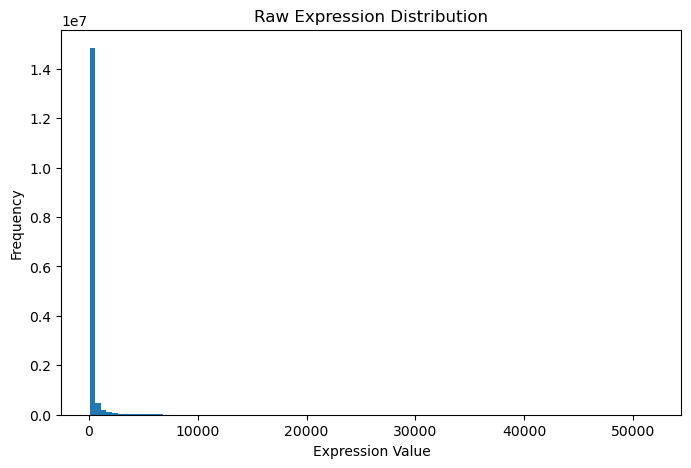

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(gse63060_clean.iloc[:,1:].stack(), bins=100)
plt.xlabel("Expression Value")
plt.ylabel("Frequency")
plt.title("Raw Expression Distribution")
plt.show()

In [91]:
import numpy as np

expr_log2 = gse63060_clean.copy()

expr_log2.iloc[:,1:] = np.log2(expr_log2.iloc[:,1:] + 1)

In [92]:
expr_log2.iloc[:,1:].stack().describe()

count    1.590978e+07
mean     7.338956e+00
std      1.074315e+00
min      6.114309e+00
25%      6.802403e+00
50%      6.969888e+00
75%      7.308896e+00
max      1.566180e+01
dtype: float64

In [93]:
metadata_clean = metadata[
    metadata['sample_title'].isin(expr_samples)
].copy()

metadata_clean.shape

(326, 2)

In [94]:
metadata_clean['status'].value_counts()

status
AD     142
CTL    104
MCI     80
Name: count, dtype: int64

In [95]:
expr_t = expr_log2.set_index('IND_ID').T

expr_t.shape

(326, 48803)

In [96]:
expr_t.head()

IND_ID,ILMN_1762337,ILMN_2055271,ILMN_1736007,ILMN_2383229,ILMN_1806310,ILMN_1779670,ILMN_2321282,ILMN_1671474,ILMN_1772582,ILMN_1735698,...,ILMN_2348512,ILMN_1743643,ILMN_1794932,ILMN_1723439,ILMN_1656676,ILMN_2371169,ILMN_1701875,ILMN_1786396,ILMN_1653618,ILMN_2137536
4856076025_A.AVG_Signal,6.699173,6.970724,6.953507,6.892631,6.899249,7.141799,7.321941,6.853213,7.055324,6.864311,...,7.358663,8.005833,6.953869,6.867295,11.048846,11.858075,11.966501,8.516382,7.562423,7.266669
4856050046_J.AVG_Signal,6.819954,7.017793,6.953095,7.031219,7.014715,6.933357,7.133656,6.908951,6.806043,7.001310,...,7.391657,8.475442,6.861557,6.803859,11.177446,12.282959,12.927444,9.093021,7.406213,7.209291
4856076025_K.AVG_Signal,6.847699,7.186060,7.105640,6.908305,6.917540,7.051710,7.070118,6.876906,6.963404,6.952242,...,7.371879,8.371422,6.881644,6.862201,10.941746,11.949764,12.524908,8.908847,7.699842,7.330149
4856076002_I.AVG_Signal,6.734375,7.005718,6.668919,6.612083,6.925724,6.897384,7.074804,6.833055,6.846526,6.838982,...,7.216413,7.931834,6.833352,6.863413,10.211561,11.519251,11.966190,8.438410,7.272904,7.115195
4856076007_I.AVG_Signal,6.909448,7.022044,6.926818,6.751061,6.985396,6.997988,7.205212,7.012096,6.896282,7.005924,...,7.365660,8.365400,6.904218,6.795606,11.225278,11.972767,12.401230,9.170424,7.493165,7.501869


In [97]:
metadata_clean = metadata_clean.set_index('sample_title')

In [98]:
expr_t.index = expr_t.index.str.replace(
    '.AVG_Signal',
    '',
    regex=False
)

In [99]:
set(expr_t.index) - set(metadata_clean.index)

set()

In [100]:
set(metadata_clean.index) - set(expr_t.index)

set()

In [101]:
expr_t['status'] = metadata_clean.loc[
    expr_t.index,
    'status'
]

In [102]:
expr_t['status'].value_counts()

status
AD     142
CTL    104
MCI     80
Name: count, dtype: int64

In [103]:
expr_t.head()

IND_ID,ILMN_1762337,ILMN_2055271,ILMN_1736007,ILMN_2383229,ILMN_1806310,ILMN_1779670,ILMN_2321282,ILMN_1671474,ILMN_1772582,ILMN_1735698,...,ILMN_1743643,ILMN_1794932,ILMN_1723439,ILMN_1656676,ILMN_2371169,ILMN_1701875,ILMN_1786396,ILMN_1653618,ILMN_2137536,status
4856076025_A,6.699173,6.970724,6.953507,6.892631,6.899249,7.141799,7.321941,6.853213,7.055324,6.864311,...,8.005833,6.953869,6.867295,11.048846,11.858075,11.966501,8.516382,7.562423,7.266669,AD
4856050046_J,6.819954,7.017793,6.953095,7.031219,7.014715,6.933357,7.133656,6.908951,6.806043,7.001310,...,8.475442,6.861557,6.803859,11.177446,12.282959,12.927444,9.093021,7.406213,7.209291,AD
4856076025_K,6.847699,7.186060,7.105640,6.908305,6.917540,7.051710,7.070118,6.876906,6.963404,6.952242,...,8.371422,6.881644,6.862201,10.941746,11.949764,12.524908,8.908847,7.699842,7.330149,AD
4856076002_I,6.734375,7.005718,6.668919,6.612083,6.925724,6.897384,7.074804,6.833055,6.846526,6.838982,...,7.931834,6.833352,6.863413,10.211561,11.519251,11.966190,8.438410,7.272904,7.115195,AD
4856076007_I,6.909448,7.022044,6.926818,6.751061,6.985396,6.997988,7.205212,7.012096,6.896282,7.005924,...,8.365400,6.904218,6.795606,11.225278,11.972767,12.401230,9.170424,7.493165,7.501869,AD


In [104]:
expr_t.shape

(326, 48804)

In [105]:
gene_data = expr_t.drop('status', axis= 1 )

In [106]:
gene_data.shape

(326, 48803)

In [107]:
 gene_var = gene_data.var()
 gene_var.shape

(48803,)

In [108]:
print(gene_var)

IND_ID
ILMN_1762337    0.025060
ILMN_2055271    0.034639
ILMN_1736007    0.025780
ILMN_2383229    0.029263
ILMN_1806310    0.031868
                  ...   
ILMN_2371169    0.294026
ILMN_1701875    0.280832
ILMN_1786396    0.224248
ILMN_1653618    0.252533
ILMN_2137536    0.230425
Length: 48803, dtype: float64


In [109]:
top_genes = gene_var.sort_values(ascending = False).head(2000).index


In [110]:
type(top_genes)

pandas.core.indexes.base.Index

In [111]:
top_genes[:5]

Index(['ILMN_2165753', 'ILMN_1697499', 'ILMN_1783142', 'ILMN_1715169',
       'ILMN_2066060'],
      dtype='object', name='IND_ID')

In [112]:
X = gene_data[top_genes]

In [113]:
X.shape

(326, 2000)

In [114]:
X.head()

IND_ID,ILMN_2165753,ILMN_1697499,ILMN_1783142,ILMN_1715169,ILMN_2066060,ILMN_1733559,ILMN_1658283,ILMN_2383097,ILMN_1667813,ILMN_1815895,...,ILMN_2235745,ILMN_2376458,ILMN_1734696,ILMN_1827736,ILMN_1659075,ILMN_1738681,ILMN_1724250,ILMN_1748797,ILMN_2206188,ILMN_1691570
4856076025_A,12.752769,11.914128,7.053077,9.671585,8.326419,11.740949,10.304274,11.124832,9.679360,9.391555,...,11.697267,11.354917,7.637988,10.131475,8.470713,10.331115,11.071538,10.624716,10.991971,7.712559
4856050046_J,6.928357,6.917507,7.217927,7.247832,10.384729,11.388656,8.956492,9.342946,8.436790,11.363624,...,11.860587,11.667222,7.643475,10.475474,8.866492,11.036277,12.258164,10.716030,11.269724,7.616600
4856076025_K,14.478672,6.825167,11.604489,10.104177,8.687573,10.601527,9.474822,10.264107,8.585533,8.541229,...,11.360425,11.189201,7.295034,10.461013,8.709719,11.130229,12.045201,10.817897,10.495314,7.635648
4856076002_I,6.830784,6.742273,7.130127,6.897048,11.557598,12.270723,9.455447,9.378212,8.997616,11.225313,...,11.651802,11.639266,7.353643,9.968480,8.126100,9.990390,11.591880,10.096842,10.623257,7.174497
4856076007_I,14.240217,6.869920,7.759029,7.020082,11.030369,11.312230,9.867623,9.966205,9.396137,12.043228,...,12.664460,11.742726,7.413423,10.921424,8.807255,10.809877,12.268750,10.808863,11.500764,7.632190


In [115]:
## PCA 
from sklearn.decomposition import PCA

pca = PCA( n_components= 2)
pca_results = pca.fit_transform(X)

In [116]:
print(pca.explained_variance_ratio_)

[0.57891826 0.0900406 ]


In [117]:
pca_df = pd.DataFrame({
    'PC1': pca_results[:,0],
    'PC2': pca_results[:,1],
    'status': expr_t['status'].values
})

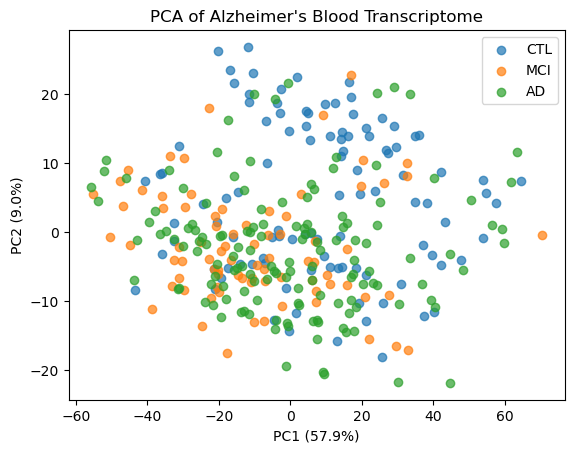

In [224]:
import matplotlib.pyplot as plt

for group in ['CTL','MCI','AD']:
    subset = pca_df[pca_df['status']==group]

    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        label=group,
        alpha=0.7
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

plt.title("PCA of Alzheimer's Blood Transcriptome")
plt.legend()

plt.savefig("pca_plot.png", dpi=300, bbox_inches="tight")

plt.show()

In [119]:
### droppping col.status - gene_data
gene_data = expr_t.drop('status', axis = 1)

In [120]:
gene_data.shape

(326, 48803)

In [121]:
## ANOVA testing
from scipy.stats import f_oneway

## creating groups for the testing
ad_samples = expr_t.index[expr_t['status'] == 'AD']
mci_samples = expr_t.index[expr_t['status'] == 'MCI']
ctl_samples = expr_t.index[expr_t['status'] == 'CTL']

In [122]:
results = []

for gene in gene_data.columns:

    ad = gene_data.loc[ad_samples, gene]
    mci = gene_data.loc[mci_samples, gene]
    ctl = gene_data.loc[ctl_samples, gene]

    f_stat, p_value = f_oneway(ad, mci, ctl)

    results.append([gene, f_stat, p_value])

anova_results = pd.DataFrame(
    results,
    columns=['Gene', 'F_stat', 'p_value']
)

In [123]:
anova_results = anova_results.sort_values('p_value')
anova_results.head(20)

,Gene,F_stat,p_value
36349,ILMN_1784286,68.950560,1.157587e-25
42641,ILMN_2128128,60.500333,4.827836e-23
36384,ILMN_1776104,57.443007,4.533084e-22
30836,ILMN_1732328,51.524469,3.788788e-20
25048,ILMN_1803775,50.891596,6.126107e-20
8381,ILMN_2166865,49.843519,1.361915e-19
46956,ILMN_1759453,49.328719,2.019320e-19
28878,ILMN_1711729,49.096845,2.412057e-19
1905,ILMN_1726603,48.678062,3.326600e-19
32295,ILMN_1782417,48.270593,4.551024e-19


In [124]:
## Apply Benjamini-Hochberg FDR
from statsmodels.stats.multitest import multipletests

anova_results['FDR'] = multipletests(
    anova_results['p_value'],
    method='fdr_bh'
)[1]

In [125]:
anova_results = anova_results.sort_values('FDR')

In [126]:
anova_results.head(20)

,Gene,F_stat,p_value,FDR
36349,ILMN_1784286,68.950560,1.157587e-25,5.649372e-21
42641,ILMN_2128128,60.500333,4.827836e-23,1.178064e-18
36384,ILMN_1776104,57.443007,4.533084e-22,7.374270e-18
30836,ILMN_1732328,51.524469,3.788788e-20,4.622606e-16
25048,ILMN_1803775,50.891596,6.126107e-20,5.979448e-16
8381,ILMN_2166865,49.843519,1.361915e-19,1.107759e-15
46956,ILMN_1759453,49.328719,2.019320e-19,1.407841e-15
28878,ILMN_1711729,49.096845,2.412057e-19,1.471445e-15
1905,ILMN_1726603,48.678062,3.326600e-19,1.803868e-15
32295,ILMN_1782417,48.270593,4.551024e-19,2.221036e-15


In [127]:
(anova_results['FDR'] < 0.05).sum()

np.int64(3647)

strong results 3647 genes still  PCA overlaps. Why?
Because PCA asks:
What explains the largest overall variation?
while ANOVA asks:
Is this specific gene associated with disease status?
These are very different questions.

In [128]:
# examine the top 20 probes
top20 = anova_results.head(20)['Gene']

for gene in top20:
    print("\n", gene)

    print(
        gene_data.loc[expr_t['status']=='CTL', gene].mean(),
        gene_data.loc[expr_t['status']=='MCI', gene].mean(),
        gene_data.loc[expr_t['status']=='AD', gene].mean()
    )


 ILMN_1784286
11.753277619144086 10.56539744461754 10.577669976335429

 ILMN_2128128
9.721874034027197 8.517092035139479 8.565391057048197

 ILMN_1776104
10.044385356613308 8.942204742582415 8.973958073309767

 ILMN_1732328
11.746210984291762 10.604382558070785 10.705904438825037

 ILMN_1803775
9.412966456973162 8.346450541408293 8.4987603661797

 ILMN_2166865
8.98488833623405 7.9566816164341585 8.11618506147343

 ILMN_1759453
7.5389811209512185 6.926426305240533 6.97702901466528

 ILMN_1711729
8.30308461558777 7.184921867382033 7.300145510254035

 ILMN_1726603
11.165703772613446 10.257275245841267 10.345057591806203

 ILMN_1782417
8.093136334213602 7.285098945032521 7.442794267037584

 ILMN_2189936
12.8886434251516 12.183834756483224 12.149140071719462

 ILMN_2229242
8.808238799664029 7.709159696127337 7.896490919008367

 ILMN_2097421
9.484602201390906 8.738472802280622 8.788876485853567

 ILMN_1719032
8.64641134130069 7.454227014253192 7.642012212495466

 ILMN_2119945
9.702659572437

In [129]:
#calculate the mean expression for all 3647 significant probes and look for monotonic trends.
sig_genes = anova_results[anova_results['FDR'] < 0.05]['Gene']

In [131]:
progression_genes = []

for gene in sig_genes:

    ctl = gene_data.loc[
        expr_t['status']=='CTL',
        gene
    ].mean()

    mci = gene_data.loc[
        expr_t['status']=='MCI',
        gene
    ].mean()

    ad = gene_data.loc[
        expr_t['status']=='AD',
        gene
    ].mean()

    if ctl < mci < ad:
        progression_genes.append(
            [gene, ctl, mci, ad, "up"]
        )

    elif ctl > mci > ad:
        progression_genes.append(
            [gene, ctl, mci, ad, "down"]
        )

In [132]:
# convert to dataframe
progression_df = pd.DataFrame(
    progression_genes,
    columns=[
        'Gene',
        'CTL',
        'MCI',
        'AD',
        'Direction'
    ]
)

In [133]:
progression_df.shape

(66, 5)

In [134]:
progression_df.head(20)

,Gene,CTL,MCI,AD,Direction
0,ILMN_2189936,12.888643,12.183835,12.149140,down
1,ILMN_1733559,9.569898,10.493472,10.785541,up
2,ILMN_1672356,9.854061,10.170462,10.238044,up
3,ILMN_1670517,8.258690,8.458306,8.536580,up
4,ILMN_1757106,9.431751,9.698899,9.781702,up
5,ILMN_1703894,8.055239,8.297146,8.360735,up
6,ILMN_1710303,7.649117,7.447286,7.437917,down
7,ILMN_1821517,12.021229,12.268471,12.313794,up
8,ILMN_1781184,7.712547,7.831605,7.955952,up
9,ILMN_1693630,8.781246,8.935296,9.075947,up


In [135]:
# adding a minimum effect size filter.
progression_df['Change'] = abs(
    progression_df['AD'] - progression_df['CTL']
)

progression_df.sort_values(
    'Change',
    ascending=False
).head(20)

,Gene,CTL,MCI,AD,Direction,Change
1,ILMN_1733559,9.569898,10.493472,10.785541,up,1.215643
0,ILMN_2189936,12.888643,12.183835,12.149140,down,0.739503
32,ILMN_1755537,7.727722,7.477686,7.227164,down,0.500557
2,ILMN_1672356,9.854061,10.170462,10.238044,up,0.383983
4,ILMN_1757106,9.431751,9.698899,9.781702,up,0.349951
12,ILMN_1832879,10.468569,10.758313,10.806080,up,0.337510
10,ILMN_1711994,10.799538,11.024191,11.128912,up,0.329375
18,ILMN_2195821,10.749646,10.784776,11.061379,up,0.311732
5,ILMN_1703894,8.055239,8.297146,8.360735,up,0.305497
34,ILMN_2072598,10.482626,10.690957,10.778815,up,0.296188


In [136]:
strong_markers = progression_df[
    progression_df["Change"] > 0.5
]

strong_markers

,Gene,CTL,MCI,AD,Direction,Change
0,ILMN_2189936,12.888643,12.183835,12.149140,down,0.739503
1,ILMN_1733559,9.569898,10.493472,10.785541,up,1.215643
32,ILMN_1755537,7.727722,7.477686,7.227164,down,0.500557


In [138]:
## annotation file 

with open("GPL6947.annot", "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

print(lines[:50])

['^Annotation\n', '!Annotation_date = Aug 09 2016\n', '!Annotation_platform = GPL6947\n', '!Annotation_platform_title = Illumina HumanHT-12 V3.0 expression beadchip\n', '!Annotation_platform_organism = Homo sapiens\n', '#ID = ID from Platform data table\n', '#Gene title = Entrez Gene name\n', '#Gene symbol = Entrez Gene symbol\n', '#Gene ID = Entrez Gene identifier\n', '#UniGene title = Entrez UniGene name\n', '#UniGene symbol = Entrez UniGene symbol\n', '#UniGene ID = Entrez UniGene identifier\n', '#Nucleotide Title = Entrez Nucleotide title\n', '#GI = GenBank identifier\n', '#GenBank Accession = GenBank accession\n', '#Platform_CLONEID = CLONE_ID from Platform data table\n', '#Platform_ORF = ORF from Platform data table\n', '#Platform_SPOTID = SPOT_ID from Platform data table\n', '#Chromosome location = Entrez gene chromosome and location\n', '#Chromosome annotation = Entrez gene chromosome annotation\n', '#GO:Function = Gene Ontology Function term\n', '#GO:Process = Gene Ontology Pr

In [139]:
for line in lines:
    if "ILMN_1733559" in line:
        print(line)
        break

ILMN_1733559	RNA, 28S ribosomal 5	RNA28S5	100008589				Homo sapiens RNA, 28S ribosomal 5 (RNA28S5), ribosomal RNA	225637499	NR_003287				22p12	Chromosome 22							GCGGGCCGCCGGTGAAATACCACTACTCTGATCGTTTTTTCACTGACCCG



In [141]:
for line in lines:
    if "ILMN_2189936" in line:
        print(line)
        break

ILMN_2189936	ribosomal protein L36a like	RPL36AL	6166				Homo sapiens ribosomal protein L36a like (RPL36AL), mRNA	453040294	NM_001001				14q21	Chromosome 14, NC_000014.9 (49618688..49620685, complement)	protein binding///structural constituent of ribosome	response to retinoic acid///translation	cytosolic large ribosomal subunit///nucleus	GO:0005515///GO:0003735	GO:0032526///GO:0006412	GO:0022625///GO:0005634	CGAGAGCTGCGAAGGGCCAGGTGTCGGGCGCTGTTTCTCGTTTTCATCAT



In [142]:
for line in lines:
    if "ILMN_1755537" in line:
        print(line)
        break

ILMN_1755537	eukaryotic translation initiation factor 1A, Y-linked	EIF1AY	9086				Homo sapiens eukaryotic translation initiation factor 1A, Y-linked (EIF1AY), transcript variant 1, mRNA	519666786	NM_004681				Yq11.223	Chromosome Y, NC_000024.10 (20575711..20593154)	protein binding///translation initiation factor activity	translational initiation		GO:0005515///GO:0003743	GO:0006413		CTGAGGATGGTTCTACAGTTGGGATTTTGGCCATCATCAACCAAGAAGAG



In [146]:
with open("GPL6947.annot", "r", encoding="utf-8", errors="ignore") as f:
    for i in range(40):
        print(i, repr(f.readline()))

0 '^Annotation\n'
1 '!Annotation_date = Aug 09 2016\n'
2 '!Annotation_platform = GPL6947\n'
3 '!Annotation_platform_title = Illumina HumanHT-12 V3.0 expression beadchip\n'
4 '!Annotation_platform_organism = Homo sapiens\n'
5 '#ID = ID from Platform data table\n'
6 '#Gene title = Entrez Gene name\n'
7 '#Gene symbol = Entrez Gene symbol\n'
8 '#Gene ID = Entrez Gene identifier\n'
9 '#UniGene title = Entrez UniGene name\n'
10 '#UniGene symbol = Entrez UniGene symbol\n'
11 '#UniGene ID = Entrez UniGene identifier\n'
12 '#Nucleotide Title = Entrez Nucleotide title\n'
13 '#GI = GenBank identifier\n'
14 '#GenBank Accession = GenBank accession\n'
15 '#Platform_CLONEID = CLONE_ID from Platform data table\n'
16 '#Platform_ORF = ORF from Platform data table\n'
17 '#Platform_SPOTID = SPOT_ID from Platform data table\n'
18 '#Chromosome location = Entrez gene chromosome and location\n'
19 '#Chromosome annotation = Entrez gene chromosome annotation\n'
20 '#GO:Function = Gene Ontology Function term\n'


In [236]:
annot = pd.read_csv(
    "GPL6947.annot",
    sep="\t",
    skiprows=28,
    low_memory=False
)

In [237]:
annot.shape


(49577, 22)

In [151]:
annot_small = annot[
    ["ID", "Gene symbol", "Gene title"]
]

In [153]:
annot_small.head()

,ID,Gene symbol,Gene title
0,ILMN_1725881,NaN,NaN
1,ILMN_1910180,NRP2,neuropilin 2
2,ILMN_1804174,FCGR2B,Fc fragment of IgG receptor IIb
3,ILMN_1796063,TRIM44,tripartite motif containing 44
4,ILMN_1811966,NaN,NaN


In [154]:
## annotate 66 progression genes
progression_annot = progression_df.merge(
    annot_small,
    left_on="Gene",
    right_on="ID",
    how="left"
)

In [155]:
progression_annot[
    ["Gene", "Gene symbol", "Gene title", "Change"]
].head(20)

,Gene,Gene symbol,Gene title,Change
0,ILMN_2189936,RPL36AL,ribosomal protein L36a like,0.739503
1,ILMN_1733559,RNA28S5,"RNA, 28S ribosomal 5",1.215643
2,ILMN_1672356,ANKRD13D,ankyrin repeat domain 13D,0.383983
3,ILMN_1670517,NaN,NaN,0.277890
4,ILMN_1757106,MARCH6,membrane associated ring-CH-type finger 6,0.349951
5,ILMN_1703894,BOLA2,bolA family member 2,0.305497
6,ILMN_1710303,TTC25,tetratricopeptide repeat domain 25,0.211199
7,ILMN_1821517,NaN,NaN,0.292565
8,ILMN_1781184,MYBPC3,"myosin binding protein C, cardiac",0.243404
9,ILMN_1693630,VPS9D1,VPS9 domain containing 1,0.294701


In [157]:
progression_annot["Gene symbol"].value_counts().head(20)

Gene symbol
CREBRF      2
BOLA2       2
RPL36AL     1
C7orf43     1
ITGAX       1
NBEAL2      1
CRIPAK      1
STAB1       1
KLHDC8B     1
UBA7        1
CPEB4       1
KAZN        1
FAM160A2    1
HELZ2       1
OSCAR       1
RAB24       1
HK3         1
DPCD        1
MBD6        1
STK11IP     1
Name: count, dtype: int64

In [158]:
progression_annot[
    ["Gene symbol", "Gene title", "Direction", "Change"]
].head(30)

,Gene symbol,Gene title,Direction,Change
0,RPL36AL,ribosomal protein L36a like,down,0.739503
1,RNA28S5,"RNA, 28S ribosomal 5",up,1.215643
2,ANKRD13D,ankyrin repeat domain 13D,up,0.383983
3,NaN,NaN,up,0.277890
4,MARCH6,membrane associated ring-CH-type finger 6,up,0.349951
5,BOLA2,bolA family member 2,up,0.305497
6,TTC25,tetratricopeptide repeat domain 25,down,0.211199
7,NaN,NaN,up,0.292565
8,MYBPC3,"myosin binding protein C, cardiac",up,0.243404
9,VPS9D1,VPS9 domain containing 1,up,0.294701


In [159]:
progression_annot["Gene symbol"].isna().sum()

np.int64(12)

In [160]:
len(progression_annot)

66

In [161]:
gene_list = progression_annot["Gene symbol"].dropna().unique()

In [162]:
len(gene_list)

52

In [163]:
## 20 genes with the largest CTL→AD change.
progression_annot.sort_values(
    "Change",
    ascending=False
)[["Gene symbol","Gene title","Direction","Change"]].head(20)

,Gene symbol,Gene title,Direction,Change
1,RNA28S5,"RNA, 28S ribosomal 5",up,1.215643
0,RPL36AL,ribosomal protein L36a like,down,0.739503
32,EIF1AY,"eukaryotic translation initiation factor 1A, Y...",down,0.500557
2,ANKRD13D,ankyrin repeat domain 13D,up,0.383983
4,MARCH6,membrane associated ring-CH-type finger 6,up,0.349951
12,NaN,NaN,up,0.337510
10,TCIRG1,"T-cell immune regulator 1, ATPase H+ transport...",up,0.329375
18,CREBRF,CREB3 regulatory factor,up,0.311732
5,BOLA2,bolA family member 2,up,0.305497
34,LOC401357,uncharacterized LOC401357,up,0.296188


In [167]:
## checking whether ribosomal gene play a big part
gene_symbols = progression_annot["Gene symbol"].dropna()

In [168]:
gene_symbols[gene_symbols.str.startswith("RPL")]

0    RPL36AL
Name: Gene symbol, dtype: object

In [172]:
gene_symbols[gene_symbols.str.startswith("EIF")]

32    EIF1AY
Name: Gene symbol, dtype: object

from results only 2 genes RPL36AL and  EIF1AY are only there involved so not that significant(though they were the top genes) focusing back on other genes

In [173]:
gene_list = progression_annot["Gene symbol"].dropna().unique()

len(gene_list)


52

In [174]:
## creating a data frame for enrichment of pathway genes
gene_df = pd.DataFrame({"Gene": gene_list})

gene_df.to_csv(
    "progression_genes.csv",
    index=False
)

In [175]:
gene_list[:20]

array(['RPL36AL', 'RNA28S5', 'ANKRD13D', 'MARCH6', 'BOLA2', 'TTC25',
       'MYBPC3', 'VPS9D1', 'TCIRG1', 'SDF4', 'LINC00999', 'RAB37',
       'DCUN1D1', 'SHKBP1', 'CREBRF', 'FOXO3', 'THBS1', 'DPRXP4', 'RYBP',
       'SNTB2'], dtype=object)

52 annotated progression-associated genes were identified. Preliminary inspection suggests enrichment of immune-regulatory (TCIRG1, ITGAX, TYK2), stress-response (FOXO3, CREBRF), vesicular trafficking (RAB37, VPS9D1), and protein quality-control pathways (MARCH6), rather than a dominant ribosomal signature.

In [178]:
genes = progression_annot[
    progression_annot["Gene symbol"].notna()
]

In [179]:
genes["Gene symbol"].tolist()

['RPL36AL',
 'RNA28S5',
 'ANKRD13D',
 'MARCH6',
 'BOLA2',
 'TTC25',
 'MYBPC3',
 'VPS9D1',
 'TCIRG1',
 'BOLA2',
 'SDF4',
 'LINC00999',
 'RAB37',
 'DCUN1D1',
 'SHKBP1',
 'CREBRF',
 'FOXO3',
 'THBS1',
 'DPRXP4',
 'RYBP',
 'SNTB2',
 'ZSWIM8',
 'RDH5',
 'TYK2',
 'SLX1A',
 'CREBRF',
 'EIF1AY',
 'APBB3',
 'LOC401357',
 'RAB24',
 'LINC00936',
 'C7orf43',
 'ITGAX',
 'NBEAL2',
 'CRIPAK',
 'STAB1',
 'KLHDC8B',
 'UBA7',
 'CPEB4',
 'KAZN',
 'FAM160A2',
 'HELZ2',
 'OSCAR',
 'HK3',
 'DPCD',
 'MBD6',
 'STK11IP',
 'ABCA7',
 'CECR6',
 'LINC01451',
 'NPEPL1',
 'ASAP1',
 'TROVE2',
 'ADCY4']

In [180]:
genes["Direction"].value_counts()

Direction
up      49
down     5
Name: count, dtype: int64

In [181]:
genes[genes["Direction"]=="down"][
    ["Gene symbol","Gene title","Change"]
]

,Gene symbol,Gene title,Change
0,RPL36AL,ribosomal protein L36a like,0.739503
6,TTC25,tetratricopeptide repeat domain 25,0.211199
13,SDF4,stromal cell derived factor 4,0.278686
32,EIF1AY,"eukaryotic translation initiation factor 1A, Y...",0.500557
53,DPCD,deleted in primary ciliary dyskinesia homolog ...,0.121868


In [182]:
progression_annot.sort_values(
    "Change",
    ascending=False
)[
    ["Gene symbol","Gene title","Direction","Change"]
]

,Gene symbol,Gene title,Direction,Change
1,RNA28S5,"RNA, 28S ribosomal 5",up,1.215643
0,RPL36AL,ribosomal protein L36a like,down,0.739503
32,EIF1AY,"eukaryotic translation initiation factor 1A, Y...",down,0.500557
2,ANKRD13D,ankyrin repeat domain 13D,up,0.383983
4,MARCH6,membrane associated ring-CH-type finger 6,up,0.349951
...,...,...,...,...
28,RDH5,retinol dehydrogenase 5,up,0.155796
58,NaN,NaN,up,0.155747
48,KAZN,"kazrin, periplakin interacting protein",up,0.150143
57,NaN,NaN,up,0.142954


In [183]:
progression_annot.sort_values(
    "Change",
    ascending=False
).to_csv(
    "progression_genes_ranked.csv",
    index=False
)

In [184]:
top_up = progression_annot[
    progression_annot["Direction"]=="up"
].sort_values(
    "Change",
    ascending=False
)

top_up[
    ["Gene symbol","Gene title","Change"]
].head(20)

,Gene symbol,Gene title,Change
1,RNA28S5,"RNA, 28S ribosomal 5",1.215643
2,ANKRD13D,ankyrin repeat domain 13D,0.383983
4,MARCH6,membrane associated ring-CH-type finger 6,0.349951
12,NaN,NaN,0.337510
10,TCIRG1,"T-cell immune regulator 1, ATPase H+ transport...",0.329375
18,CREBRF,CREB3 regulatory factor,0.311732
5,BOLA2,bolA family member 2,0.305497
34,LOC401357,uncharacterized LOC401357,0.296188
9,VPS9D1,VPS9 domain containing 1,0.294701
22,RYBP,RING1 and YY1 binding protein,0.293166


In [185]:
progression_annot["Gene symbol"].value_counts().head(20)

Gene symbol
CREBRF      2
BOLA2       2
RPL36AL     1
C7orf43     1
ITGAX       1
NBEAL2      1
CRIPAK      1
STAB1       1
KLHDC8B     1
UBA7        1
CPEB4       1
KAZN        1
FAM160A2    1
HELZ2       1
OSCAR       1
RAB24       1
HK3         1
DPCD        1
MBD6        1
STK11IP     1
Name: count, dtype: int64

Analysis of 326 blood transcriptomes from controls, MCI, and Alzheimer's disease patients identified 66 progression-associated probes corresponding to 52 annotated genes. Most genes (49/54 annotated probes) showed increased expression with disease progression. Prominent biological themes included immune regulation (ITGAX, TCIRG1), cellular stress responses (CREBRF, FOXO3), intracellular trafficking (RAB37, VPS9D1), and protein quality-control mechanisms (MARCH6).

In [186]:
gene_expr = expr_t[
    progression_annot["Gene"].dropna().unique()
]

In [189]:
expr_t.shape


(326, 48804)

In [190]:
expr_t.columns[:5]

Index(['ILMN_1762337', 'ILMN_2055271', 'ILMN_1736007', 'ILMN_2383229',
       'ILMN_1806310'],
      dtype='object', name='IND_ID')

In [191]:
progression_annot.columns

Index(['Gene', 'CTL', 'MCI', 'AD', 'Direction', 'Change', 'ID', 'Gene symbol',
       'Gene title'],
      dtype='object')

In [192]:
progression_annot.shape

(66, 9)

In [193]:
progression_annot["Gene"].head()

0    ILMN_2189936
1    ILMN_1733559
2    ILMN_1672356
3    ILMN_1670517
4    ILMN_1757106
Name: Gene, dtype: object

In [194]:
gene_list = progression_annot["Gene symbol"].dropna().unique()

In [195]:
len(gene_list)

52

In [196]:
gene_list

array(['RPL36AL', 'RNA28S5', 'ANKRD13D', 'MARCH6', 'BOLA2', 'TTC25',
       'MYBPC3', 'VPS9D1', 'TCIRG1', 'SDF4', 'LINC00999', 'RAB37',
       'DCUN1D1', 'SHKBP1', 'CREBRF', 'FOXO3', 'THBS1', 'DPRXP4', 'RYBP',
       'SNTB2', 'ZSWIM8', 'RDH5', 'TYK2', 'SLX1A', 'EIF1AY', 'APBB3',
       'LOC401357', 'RAB24', 'LINC00936', 'C7orf43', 'ITGAX', 'NBEAL2',
       'CRIPAK', 'STAB1', 'KLHDC8B', 'UBA7', 'CPEB4', 'KAZN', 'FAM160A2',
       'HELZ2', 'OSCAR', 'HK3', 'DPCD', 'MBD6', 'STK11IP', 'ABCA7',
       'CECR6', 'LINC01451', 'NPEPL1', 'ASAP1', 'TROVE2', 'ADCY4'],
      dtype=object)

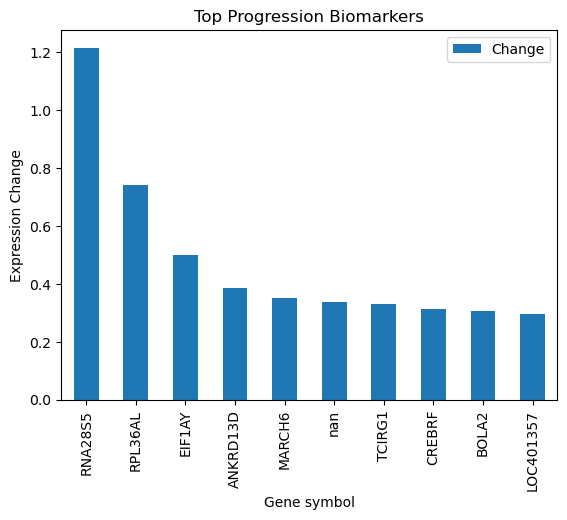

In [232]:
## Top progession biomarkers (for image)
top10 = progression_annot.sort_values(
    "Change",
    ascending=False
).head(10)

top10.plot(
    x="Gene symbol",
    y="Change",
    kind="bar"
)

Top progression genes : 

ANOVA
  ↓
Significant genes (FDR corrected)
  ↓
Progression filtering
(CTL → MCI → AD trend)
  ↓
Calculate Change
  ↓
Rank by Change

They were identified by first performing ANOVA with FDR correction to detect significant expression differences across CTL, MCI, and AD groups, followed by filtering for monotonic expression trends across disease progression stages (CTL→MCI→AD or CTL→MCI→AD decreasing). Genes were then ranked according to the magnitude of expression change between CTL and AD.

In [198]:
## predictive modelling 
selected_probes = progression_annot["Gene"].unique()

X = expr_t[selected_probes]

y = expr_t["status"]

print(X.shape)
print(y.shape)

(326, 66)
(326,)


In [200]:
## train_test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(260, 66)
(66, 66)


In [201]:
## Random forest CTL VS MCI VS AD
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [203]:
pred = rf.predict(X_test)

In [204]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

          AD       0.53      0.79      0.64        29
         CTL       0.79      0.52      0.63        21
         MCI       0.22      0.12      0.16        16

    accuracy                           0.55        66
   macro avg       0.51      0.48      0.48        66
weighted avg       0.54      0.55      0.52        66



In [205]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, pred)

0.5454545454545454

In [206]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

          AD       0.53      0.79      0.64        29
         CTL       0.79      0.52      0.63        21
         MCI       0.22      0.12      0.16        16

    accuracy                           0.55        66
   macro avg       0.51      0.48      0.48        66
weighted avg       0.54      0.55      0.52        66



PCA suggests: Disease status explains some variation but not enough to cleanly separate groups.
ML suggests : Disease status contains predictive information but not enough to reliably separate MCI.( recall of MCI- 0.12 % (The model correctly identified only 12% of MCI patients.)) Also accuracy is 55% (random guessing of entry in this with 3 status is 33% , 55% > 33% meaning there is definitely disease-related signal in your 66-gene signature.)

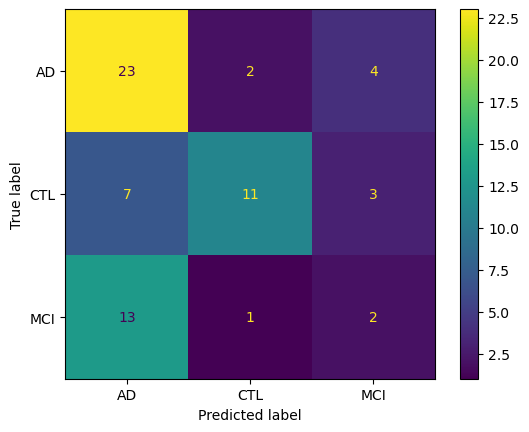

In [207]:
## confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred
)

from confusion matrix the model  suggests: Most MCI patients look more like AD than healthy controls (MCI  predcited as AD is 13)
The classifier frequently assigned MCI subjects to the AD class, suggesting that blood transcriptomic signatures of MCI resemble those observed in Alzheimer's disease

In [208]:
## feature importance
importance = pd.DataFrame({
    "Probe": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(20)

,Probe,Importance
0,ILMN_2189936,0.067914
1,ILMN_1733559,0.046242
13,ILMN_2378257,0.025604
5,ILMN_1703894,0.025530
53,ILMN_2047112,0.024266
23,ILMN_1690616,0.022149
20,ILMN_1686116,0.021837
6,ILMN_1710303,0.021001
48,ILMN_1798458,0.020348
4,ILMN_1757106,0.019915


In [230]:
## compare ANOVA Vs Random forest results 
top20_rf = importance.head(20)["Probe"]

top20_rf

0     ILMN_2189936
1     ILMN_1733559
13    ILMN_2378257
5     ILMN_1703894
53    ILMN_2047112
23    ILMN_1690616
20    ILMN_1686116
6     ILMN_1710303
48    ILMN_1798458
4     ILMN_1757106
18    ILMN_2195821
32    ILMN_1755537
3     ILMN_1670517
11    ILMN_1656382
7     ILMN_1821517
16    ILMN_1810719
31    ILMN_1776788
57    ILMN_2234016
17    ILMN_1765493
28    ILMN_1773395
Name: Probe, dtype: object

In [210]:
top20_genes = progression_annot[
    progression_annot["Gene"].isin(top20_rf)
][["Gene","Gene symbol","Change"]]

top20_genes.sort_values("Change", ascending=False)

,Gene,Gene symbol,Change
1,ILMN_1733559,RNA28S5,1.215643
0,ILMN_2189936,RPL36AL,0.739503
32,ILMN_1755537,EIF1AY,0.500557
4,ILMN_1757106,MARCH6,0.349951
18,ILMN_2195821,CREBRF,0.311732
5,ILMN_1703894,BOLA2,0.305497
7,ILMN_1821517,NaN,0.292565
31,ILMN_1776788,CREBRF,0.279328
13,ILMN_2378257,SDF4,0.278686
3,ILMN_1670517,NaN,0.277890


In [211]:
top20_probes = importance.head(20)["Probe"]

progression_annot[
    progression_annot["Gene"].isin(top20_probes)
][["Gene","Gene symbol","Gene title","Change"]]

,Gene,Gene symbol,Gene title,Change
0,ILMN_2189936,RPL36AL,ribosomal protein L36a like,0.739503
1,ILMN_1733559,RNA28S5,"RNA, 28S ribosomal 5",1.215643
3,ILMN_1670517,NaN,NaN,0.277890
4,ILMN_1757106,MARCH6,membrane associated ring-CH-type finger 6,0.349951
5,ILMN_1703894,BOLA2,bolA family member 2,0.305497
6,ILMN_1710303,TTC25,tetratricopeptide repeat domain 25,0.211199
7,ILMN_1821517,NaN,NaN,0.292565
11,ILMN_1656382,BOLA2,bolA family member 2,0.265443
13,ILMN_2378257,SDF4,stromal cell derived factor 4,0.278686
16,ILMN_1810719,DCUN1D1,defective in cullin neddylation 1 domain conta...,0.244576


In [212]:
## cross_validation
selected_probes = progression_annot["Gene"].unique()

X = expr_t[selected_probes]
y = expr_t["status"]

In [213]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Fold accuracies:", scores)
print("Mean accuracy:", scores.mean())
print("Std:", scores.std())

Fold accuracies: [0.51515152 0.63076923 0.50769231 0.50769231 0.55384615]
Mean accuracy: 0.543030303030303
Std: 0.047095385574925146


In [214]:
f1_scores = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring="f1_macro"
)

print("Mean F1-macro:", f1_scores.mean())
print("Std:", f1_scores.std())

Mean F1-macro: 0.47154640741204457
Std: 0.056462931257236205


In [215]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

pred_cv = cross_val_predict(
    rf,
    X,
    y,
    cv=cv
)

print(classification_report(y, pred_cv))

              precision    recall  f1-score   support

          AD       0.53      0.77      0.62       142
         CTL       0.70      0.56      0.62       104
         MCI       0.28      0.12      0.17        80

    accuracy                           0.54       326
   macro avg       0.50      0.48      0.47       326
weighted avg       0.52      0.54      0.51       326



In [216]:
## AD vs Ctl classification 
ad_ctl = expr_t[expr_t["status"].isin(["AD", "CTL"])]

print(ad_ctl["status"].value_counts())

status
AD     142
CTL    104
Name: count, dtype: int64


In [217]:
selected_probes = progression_annot["Gene"].unique()

X = ad_ctl[selected_probes]

y = ad_ctl["status"]

print(X.shape)
print(y.shape)

(246, 66)
(246,)


In [218]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [219]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [221]:
pred = rf.predict(X_test)

In [222]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

          AD       0.70      0.90      0.79        29
         CTL       0.77      0.48      0.59        21

    accuracy                           0.72        50
   macro avg       0.74      0.69      0.69        50
weighted avg       0.73      0.72      0.70        50



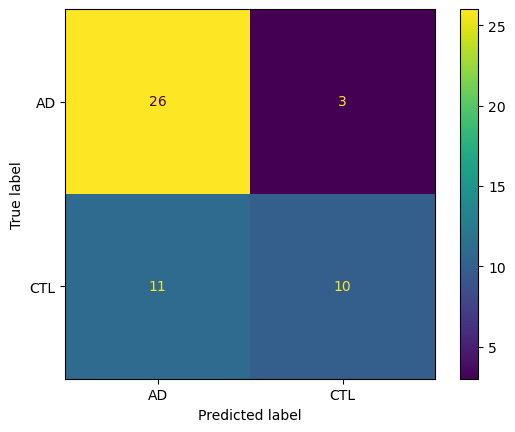

In [223]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred
)

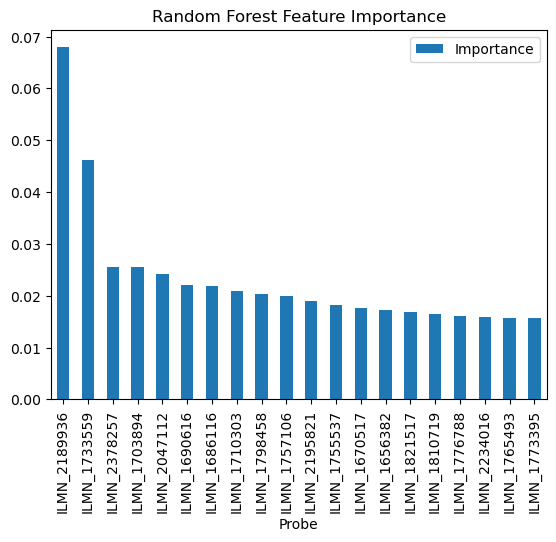

In [229]:
top20 = importance.head(20)

top20.plot(
    x="Probe",
    y="Importance",
    kind="bar"
)

plt.title("Random Forest Feature Importance")

plt.savefig(
    "rf_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [244]:
## For images
### Ctl vs MCI vs AD random forest feature importance (top 20 genes)
importance_annot = importance.merge(
    annot[["ID", "Gene symbol", "Gene title"]],
    left_on="Probe",
    right_on="ID",
    how="left"
)

In [245]:
importance_annot["Label"] = (
    importance_annot["Gene symbol"]
    .fillna(importance_annot["Probe"])
)

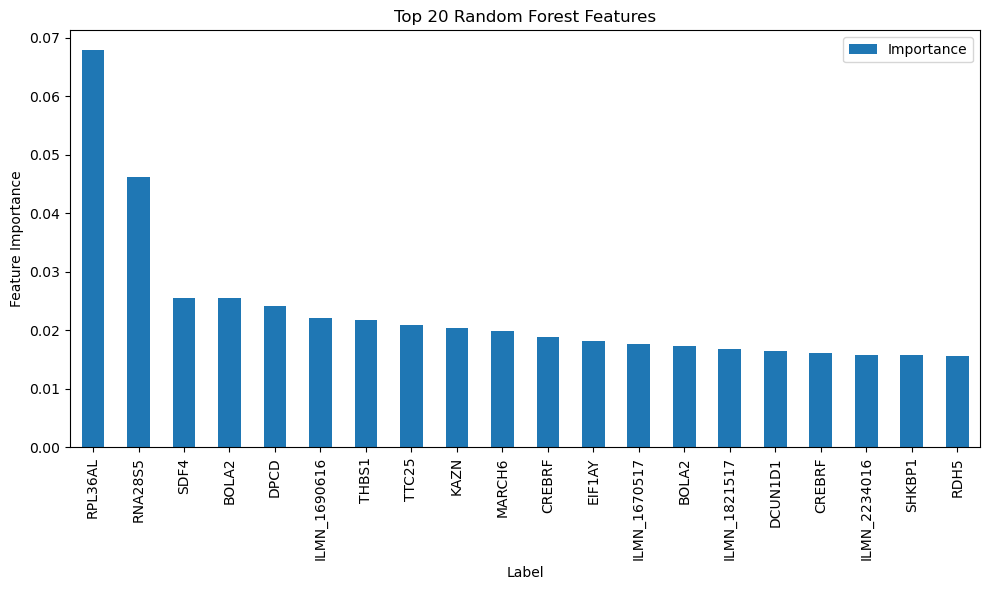

In [246]:
top20 = importance_annot.head(20)

top20.plot(
    x="Label",
    y="Importance",
    kind="bar",
    figsize=(10,6)
)

plt.title("Top 20 Random Forest Features")
plt.ylabel("Feature Importance")
plt.tight_layout()

plt.savefig(
    "rf_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [248]:
## overlapping genes between top progression and top prediction gene list

top20_rf = set(
    importance_annot.head(20)["Gene symbol"].dropna()
)

top_progression = set(
    progression_annot["Gene symbol"].dropna()
)

overlap = top20_rf.intersection(top_progression)

print(len(overlap))
print(overlap)

14
{'THBS1', 'SDF4', 'DPCD', 'MARCH6', 'CREBRF', 'RNA28S5', 'SHKBP1', 'DCUN1D1', 'EIF1AY', 'RPL36AL', 'TTC25', 'RDH5', 'KAZN', 'BOLA2'}


In [249]:
## creating a table with the 14 genes 
final_genes = [
    'THBS1','SDF4','DPCD','MARCH6',
    'CREBRF','RNA28S5','SHKBP1',
    'DCUN1D1','EIF1AY','RPL36AL',
    'TTC25','RDH5','KAZN','BOLA2'
]


In [250]:
progression_table = progression_annot[
    progression_annot["Gene symbol"].isin(final_genes)
][[
    "Gene symbol",
    "Gene title",
    "Direction",
    "Change"
]]

In [251]:
rf_table = importance_annot[
    importance_annot["Gene symbol"].isin(final_genes)
][[
    "Gene symbol",
    "Importance"
]]

In [254]:
final_table = progression_table.merge(
    rf_table,
    on="Gene symbol",
    how="left"
)

In [255]:
final_table = final_table.sort_values(
    "Importance",
    ascending=False
)

In [256]:
final_table

,Gene symbol,Gene title,Direction,Change,Importance
0,RPL36AL,ribosomal protein L36a like,down,0.739503,0.067914
1,RNA28S5,"RNA, 28S ribosomal 5",up,1.215643,0.046242
8,SDF4,stromal cell derived factor 4,down,0.278686,0.025604
6,BOLA2,bolA family member 2,up,0.265443,0.025530
3,BOLA2,bolA family member 2,up,0.305497,0.025530
19,DPCD,deleted in primary ciliary dyskinesia homolog ...,down,0.121868,0.024266
13,THBS1,thrombospondin 1,up,0.238507,0.021837
5,TTC25,tetratricopeptide repeat domain 25,down,0.211199,0.021001
18,KAZN,"kazrin, periplakin interacting protein",up,0.150143,0.020348
2,MARCH6,membrane associated ring-CH-type finger 6,up,0.349951,0.019915


In [263]:
final_table["Gene symbol"].value_counts()

Gene symbol
BOLA2      4
CREBRF     4
RPL36AL    1
RNA28S5    1
SDF4       1
DPCD       1
THBS1      1
TTC25      1
KAZN       1
MARCH6     1
EIF1AY     1
DCUN1D1    1
SHKBP1     1
RDH5       1
Name: count, dtype: int64

In [259]:
final_table.to_csv(
    "final_biomarker_candidates.csv",
    index=False
)

In [258]:
print(final_table.shape)
final_table.head()

(20, 5)


,Gene symbol,Gene title,Direction,Change,Importance
0,RPL36AL,ribosomal protein L36a like,down,0.739503,0.067914
1,RNA28S5,"RNA, 28S ribosomal 5",up,1.215643,0.046242
8,SDF4,stromal cell derived factor 4,down,0.278686,0.025604
6,BOLA2,bolA family member 2,up,0.265443,0.025530
3,BOLA2,bolA family member 2,up,0.305497,0.025530


In [264]:
final_table_unique = (
    final_table
    .sort_values("Change", ascending=False)
    .drop_duplicates(subset="Gene symbol", keep="first")
)

In [268]:
final_table_unique = final_table_unique.sort_values(
    "Importance",
    ascending=False
)

In [269]:
final_table_unique

,Gene symbol,Gene title,Direction,Change,Importance
0,RPL36AL,ribosomal protein L36a like,down,0.739503,0.067914
1,RNA28S5,"RNA, 28S ribosomal 5",up,1.215643,0.046242
8,SDF4,stromal cell derived factor 4,down,0.278686,0.025604
3,BOLA2,bolA family member 2,up,0.305497,0.025530
19,DPCD,deleted in primary ciliary dyskinesia homolog ...,down,0.121868,0.024266
13,THBS1,thrombospondin 1,up,0.238507,0.021837
5,TTC25,tetratricopeptide repeat domain 25,down,0.211199,0.021001
18,KAZN,"kazrin, periplakin interacting protein",up,0.150143,0.020348
2,MARCH6,membrane associated ring-CH-type finger 6,up,0.349951,0.019915
17,EIF1AY,"eukaryotic translation initiation factor 1A, Y...",down,0.500557,0.018184


In [270]:
final_table_unique.shape

(14, 5)

In [271]:
final_table_unique.to_csv(
    "final_unique_biomarker_candidates.csv",
    index=False
)